In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('titanic.csv')

In [3]:
df.shape

(891, 13)

In [4]:
df.columns

Index(['Unnamed: 0', 'PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   PassengerId  891 non-null    int64  
 2   Survived     891 non-null    int64  
 3   Pclass       891 non-null    int64  
 4   Name         891 non-null    str    
 5   Sex          891 non-null    str    
 6   Age          714 non-null    float64
 7   SibSp        891 non-null    int64  
 8   Parch        891 non-null    int64  
 9   Ticket       891 non-null    str    
 10  Fare         891 non-null    float64
 11  Cabin        204 non-null    str    
 12  Embarked     889 non-null    str    
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


In [6]:
df.drop(columns = ['Unnamed: 0','PassengerId','Name'],inplace = True)

In [7]:
df['GroupSize'] = 1 + df['Parch'] + df['SibSp']

In [8]:
df['Pclass'] = df['Pclass'].astype('category')                                    

In [9]:
df.describe()

,Survived,Age,SibSp,Parch,Fare,GroupSize
count,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,29.699118,0.523008,0.381594,32.204208,1.904602
std,0.486592,14.526497,1.102743,0.806057,49.693429,1.613459
min,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,20.125000,0.000000,0.000000,7.910400,1.000000
50%,0.000000,28.000000,0.000000,0.000000,14.454200,1.000000
75%,1.000000,38.000000,1.000000,0.000000,31.000000,2.000000
max,1.000000,80.000000,8.000000,6.000000,512.329200,11.000000


In [10]:
df['Survived'].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [11]:
df['Pclass'].value_counts(normalize = True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [12]:
df['Sex'].value_counts(normalize = True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [13]:
df['Ticket'].value_counts().head(10)

Ticket
347082          7
1601            7
CA. 2343        7
3101295         6
CA 2144         6
347088          6
382652          5
S.O.C. 14879    5
349909          4
347077          4
Name: count, dtype: int64

In [14]:
df['Cabin'].value_counts().head(10)

Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
F2             3
D              3
C22 C26        3
C123           2
D33            2
Name: count, dtype: int64

In [15]:
df['Embarked'].value_counts(normalize = True)

Embarked
S    0.724409
C    0.188976
Q    0.086614
Name: proportion, dtype: float64

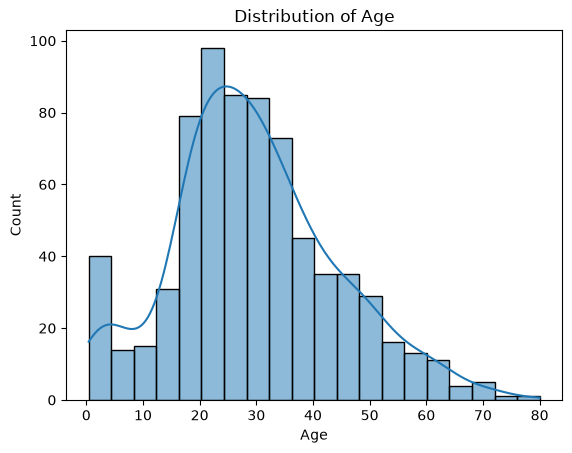

In [16]:
sns.histplot(data = df, x = 'Age',kde = True)
plt.title('Distribution of Age')
plt.show()

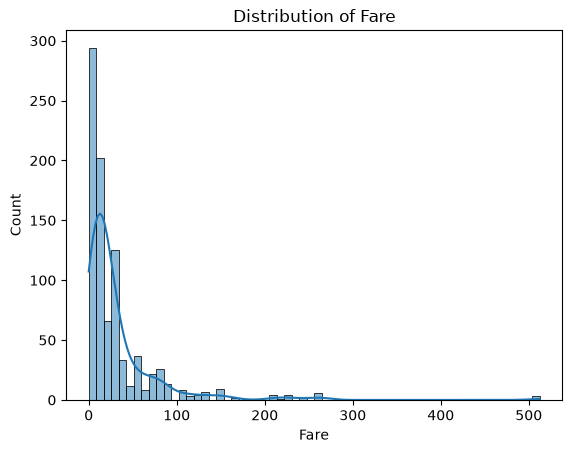

In [17]:
sns.histplot(data = df, x = 'Fare',kde = True)
plt.title('Distribution of Fare')
plt.show()

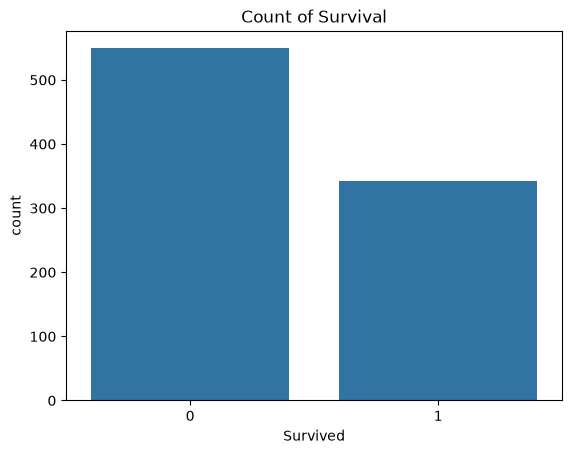

In [18]:
sns.countplot(data = df, x = 'Survived')
plt.title('Count of Survival')
plt.show()

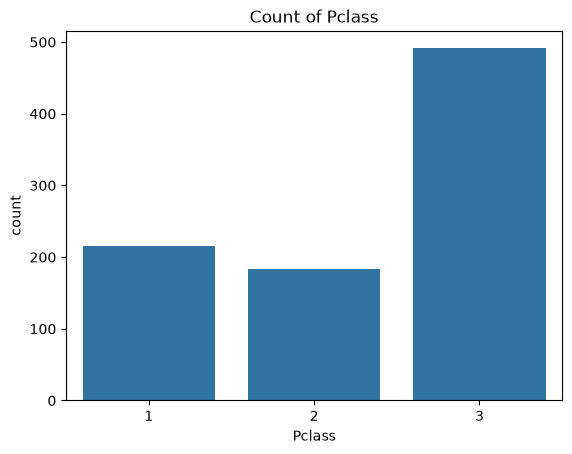

In [19]:
sns.countplot(data = df, x = 'Pclass')
plt.title('Count of Pclass')
plt.show()

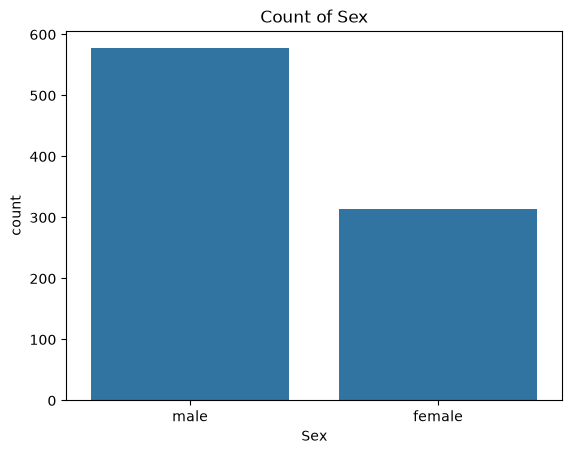

In [20]:
sns.countplot(data = df, x = 'Sex')
plt.title('Count of Sex')
plt.show()

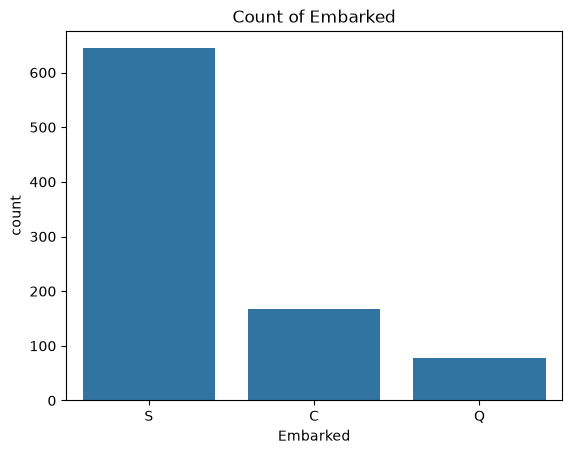

In [21]:
sns.countplot(data = df, x = 'Embarked')
plt.title('Count of Embarked')
plt.show()

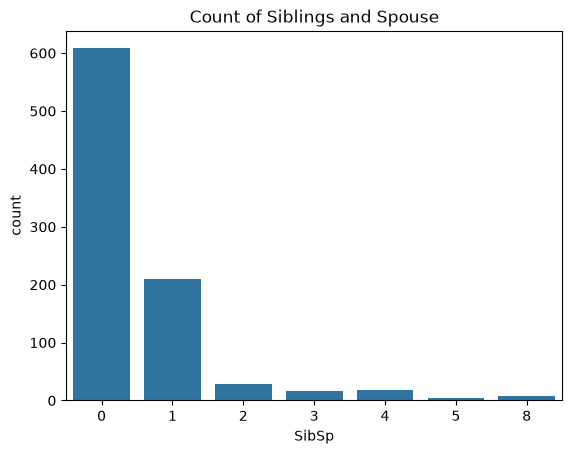

In [22]:
sns.countplot(data = df, x = 'SibSp')
plt.title('Count of Siblings and Spouse')
plt.show()

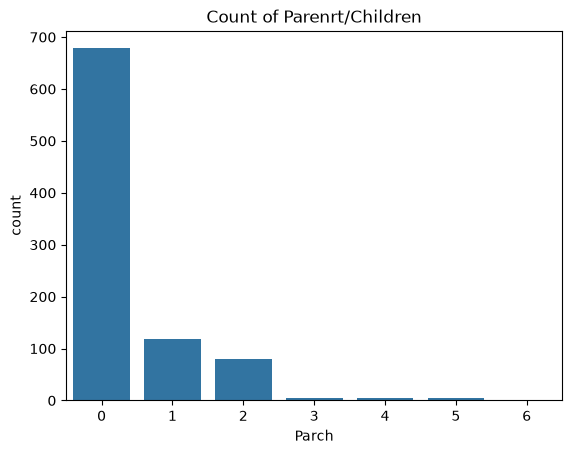

In [23]:
sns.countplot(data = df, x = 'Parch')
plt.title('Count of Parenrt/Children')
plt.show()

In [24]:
df.groupby('Survived').mean(numeric_only=True)

,Age,SibSp,Parch,Fare,GroupSize
Survived,,,,,
0,30.626179,0.553734,0.329690,22.117887,1.883424
1,28.343690,0.473684,0.464912,48.395408,1.938596


(array([0, 1, 2]), [Text(0, 0, '1'), Text(1, 0, '2'), Text(2, 0, '3')])

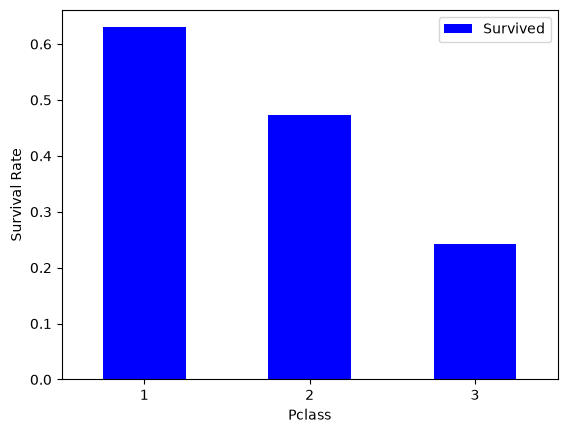

In [25]:
pclass_survival = df.groupby('Pclass')['Survived'].mean()
pclass_survival = pclass_survival.to_frame().reset_index()
pclass_survival.plot(kind = 'bar',x = 'Pclass',y = 'Survived',color = 'blue')
plt.ylabel('Survival Rate')
plt.xticks(rotation = 0)

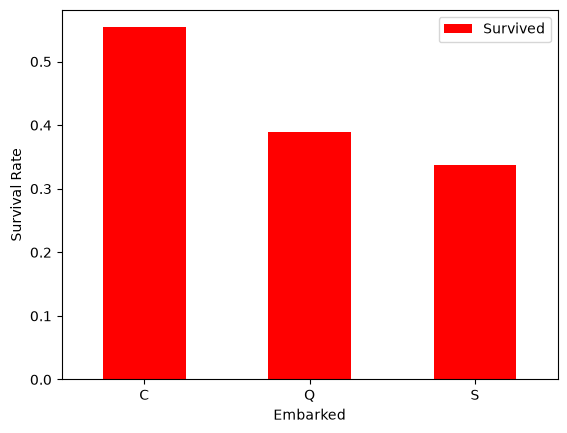

In [26]:
embarked_survival = df.groupby('Embarked')['Survived'].mean()
embarked_survival = embarked_survival.to_frame().reset_index()
embarked_survival.plot(kind = 'bar',x ='Embarked',y = 'Survived',color = 'red')
plt.ylabel('Survival Rate')
plt.xticks(rotation = 0)
plt.show()

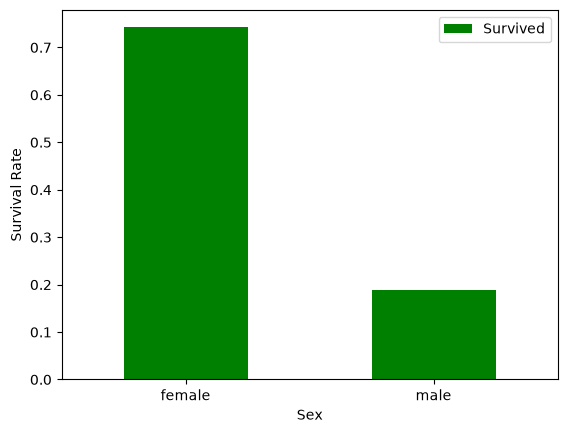

In [27]:
sex_survival = df.groupby('Sex')['Survived'].mean()
sex_survival = sex_survival.to_frame().reset_index()
sex_survival.plot(kind = 'bar', x = 'Sex',y = 'Survived',color = 'green')
plt.ylabel('Survival Rate')
plt.xticks(rotation = 0)
plt.show()

<Axes: xlabel='Survived', ylabel='Fare'>

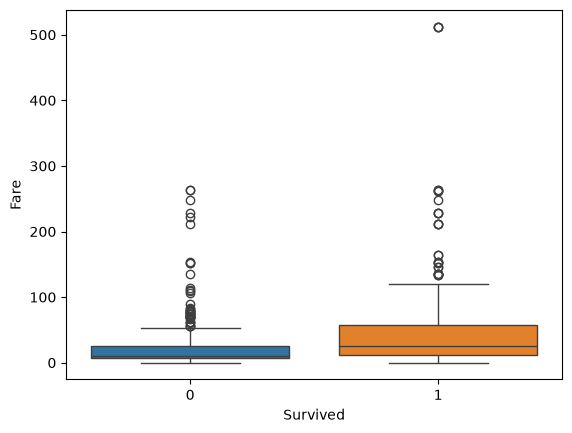

In [28]:
sns.boxplot(data=df, x='Survived', y='Fare', hue='Survived', legend=False)

<Axes: xlabel='Age', ylabel='Fare'>

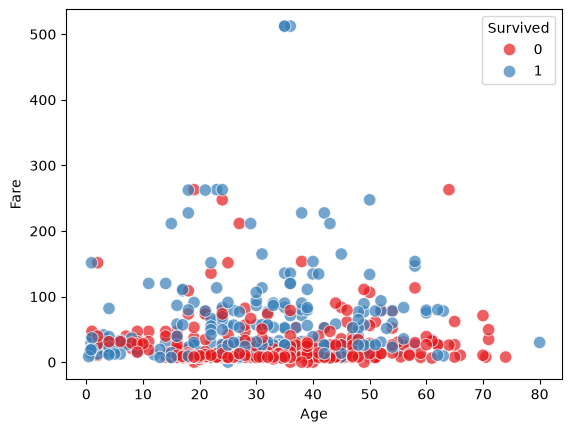

In [34]:
sns.scatterplot(
    data=df, 
    x='Age', 
    y='Fare', 
    hue='Survived',  
    palette='Set1', 
    alpha=0.7, 
    s=80
)

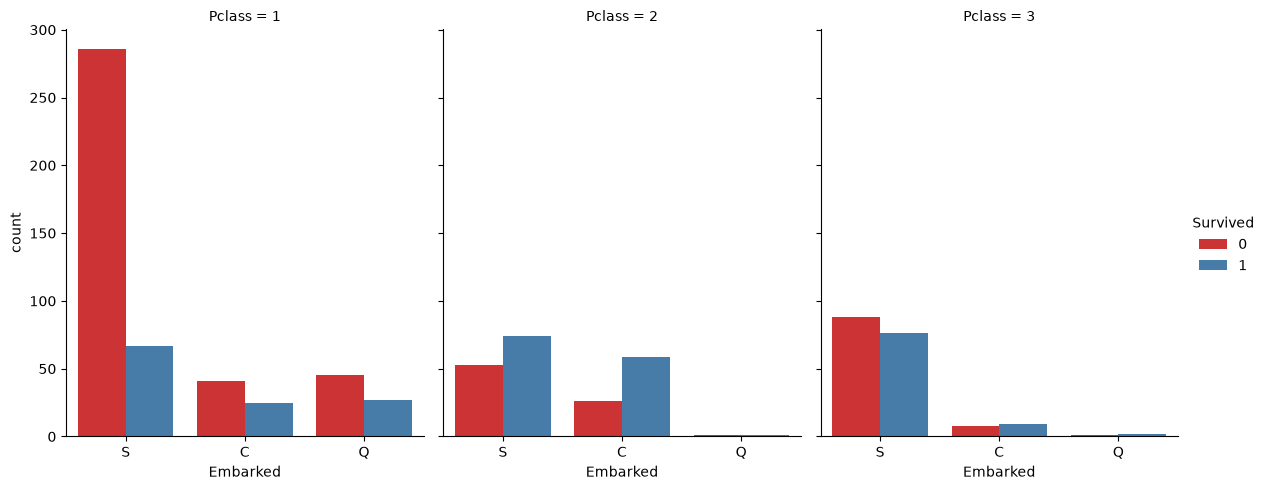

In [35]:
sns.catplot(
    data=df,
    x='Embarked',
    hue='Survived',
    col='Pclass',
    kind='count',
    palette='Set1',
    height=5,
    aspect=0.8
)

<Axes: xlabel='GroupSize', ylabel='Survived'>

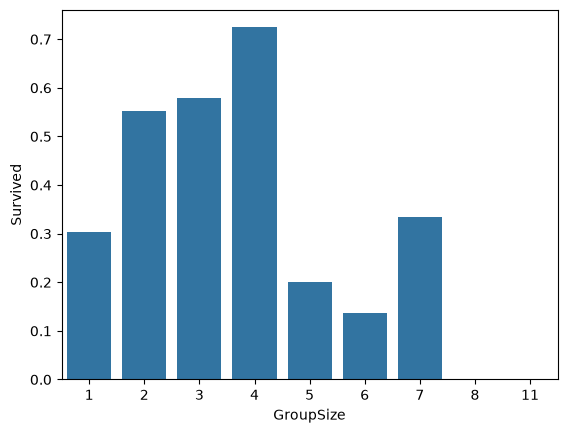

In [39]:
sns.barplot(data = df, x= 'GroupSize',y = 'Survived',errorbar=None)

In [29]:
df['Survived'] - df['Survived'].astype(int)
df['Sex'] = df['Sex'].map({'male':1,'female':0})
numerical_columns = df.select_dtypes(include=[np.number])
numerical_columns

,Survived,Sex,Age,SibSp,Parch,Fare,GroupSize
0,0,1,22.0,1,0,7.2500,2
1,1,0,38.0,1,0,71.2833,2
2,1,0,26.0,0,0,7.9250,1
3,1,0,35.0,1,0,53.1000,2
4,0,1,35.0,0,0,8.0500,1
...,...,...,...,...,...,...,...
886,0,1,27.0,0,0,13.0000,1
887,1,0,19.0,0,0,30.0000,1
888,0,0,NaN,1,2,23.4500,4
889,1,1,26.0,0,0,30.0000,1


<Axes: >

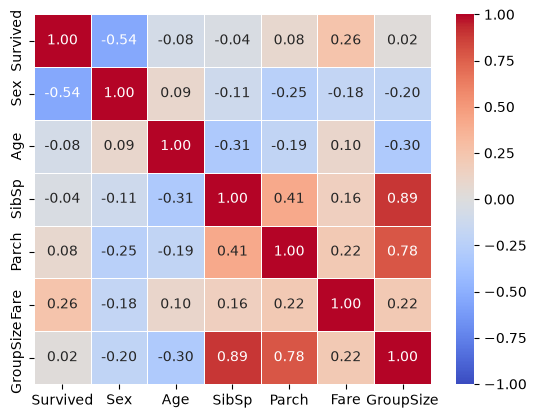

In [30]:
sns.heatmap(
    numerical_columns.corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    vmin=-1, 
    vmax=1,
    linewidths=0.5
)